# Project 2 — Deep Q-Network (DQN) on `Pong`
### RL in Production Workshop · Assignment

**Goal:** Build a **DQN from scratch in PyTorch** and train it to beat the built-in
Pong AI. You will implement the three ideas that make deep Q-learning actually work:
**experience replay**, a **target network**, and the **TD loss**.

> This is Project 1's Q-learning, but the 500-row table is replaced by a convolutional
> neural network that reads raw pixels. The update rule is *the same Bellman target* —
> we just minimize it with gradient descent.

---
### ⚠️ Before you start — runtime & expectations
- **Use a GPU runtime:** `Runtime → Change runtime type → T4 GPU`.
- Pong reaches a clearly winning policy (score **+15 to +21**) in roughly **1–3 hours**
  of training on a T4. **Start early.** Checkpointing to Google Drive (provided) lets
  you resume after Colab disconnects.
- You are graded on a *correct implementation* + evidence of learning, **not** on
  hitting +21. A reward curve that clearly trends upward past 0 is a pass.

### How this notebook works
- **`# ✅ PROVIDED`** cells (env wrappers, CNN, training loop, checkpointing, GIF) are
  done for you — read them.
- **`# 📝 TODO`** cells are yours: the **replay buffer**, the **DQN loss/optimize step**,
  the **target-network sync**, and the **epsilon schedule**.


## 1. Setup  ✅ PROVIDED

We install Gymnasium's Atari support + the ROMs, and import PyTorch.

In [1]:
# ✅ PROVIDED — install
# NOTE: opencv-python is required by AtariPreprocessing (frame resize/grayscale).
# Colab usually ships it, but we install it explicitly so the notebook is self-contained.
# !pip install -q "gymnasium[atari,accept-rom-license]==0.29.1" ale-py==0.8.1 "autorom[accept-rom-license]" opencv-python
# !AutoROM --accept-license -q || true   # ensure Atari ROMs are installed
# !pip install -q torch torchvision imageio

import os, random, time, math
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import ale_py
import matplotlib.pyplot as plt

gym.register_envs(ale_py)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", DEVICE)
assert DEVICE in ("cuda", "mps"), "Switch to a GPU or MPS runtime: Runtime → Change runtime type → T4 GPU (or MPS on Mac)"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Device: mps


## 2. Environment & preprocessing  ✅ PROVIDED — but read carefully

Raw Atari frames are 210×160 RGB and run at 60 Hz. Feeding those directly to a network
is wasteful and loses motion information. The standard **Atari preprocessing** pipeline:

1. **Grayscale + resize to 84×84** — color is irrelevant, smaller is faster.
2. **Frame-skip (4) with max-pooling** — repeat each action 4 frames; saves compute.
3. **Frame-stacking (4)** — stack the last 4 frames as channels so the network can
   perceive **velocity** (where the ball/paddle is *going*, not just where it is).
4. **Reward clipping to {−1, 0, +1}** — stabilizes the loss scale across games.

Gymnasium provides these as wrappers, so you don't have to write them.

In [4]:
# ✅ PROVIDED — build the wrapped Pong environment
from gymnasium.wrappers import AtariPreprocessing
from gymnasium.wrappers import FrameStackObservation as FrameStack

def make_env(render_mode=None):
    env = gym.make("PongNoFrameskip-v4", render_mode=render_mode)
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        grayscale_obs=True,
        scale_obs=False,      # we scale to [0,1] inside the network
    )
    env = FrameStack(env, stack_size=4)
    return env

env = make_env()
print("Observation shape:", np.array(env.reset(seed=SEED)[0]).shape)  # (4, 84, 84)
print("Number of actions:", env.action_space.n)                       # 6 for Pong

Observation shape: (4, 84, 84)
Number of actions: 6


**✍️ Quick check (write your answer):** Why do we stack **4 frames** instead of
feeding a single 84×84 image? What information would a single frame be missing?


**Answer:**
A single 84×84 frame is a static snapshot — it contains **no motion information**. From one frame alone, you can't tell:

1. **Direction of the ball** — is it moving up or down, left or right?
2. **Speed of the ball** — is it fast or slow?
3. **Paddle velocity** — is the opponent/agent moving or stationary?

Stacking 4 consecutive frames gives the network a short "history" that encodes **velocity and acceleration** implicitly. The CNN can learn to compare pixel differences across the stack to infer motion — essentially performing temporal differencing. This is the same reason our eyes need multiple frames to perceive movement.

Without frame stacking, the environment looks like a POMDP (partially observable) — the Markov property is broken because the optimal action depends on information not present in the current observation. With 4 frames stacked, the state becomes approximately Markov again.

## 3. The Q-network (CNN)  ✅ PROVIDED

This is the classic architecture from Mnih et al. (2015), *"Human-level control through
deep reinforcement learning"* (the Nature DQN paper). Input: 4×84×84. Output: one
Q-value **per action** — so a single forward pass gives `Q(s, ·)` for all actions at once.

In [5]:
# ✅ PROVIDED — Nature-DQN CNN
class QNetwork(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512), nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        # x: (B, 4, 84, 84) uint8 in [0,255] -> scale to [0,1]
        x = x.float() / 255.0
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        return self.head(x)

n_actions = env.action_space.n
net = QNetwork(n_actions).to(DEVICE)
print(net)
print("Params:", sum(p.numel() for p in net.parameters()))

QNetwork(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=6, bias=True)
  )
)
Params: 1687206


## 4. Experience Replay buffer  📝 TODO

**Why this exists:** consecutive frames are highly correlated. Training a network on
correlated samples is unstable and overfits to the recent trajectory. The replay buffer
stores transitions `(s, a, r, s', done)` and lets us sample **random minibatches** —
breaking correlation and reusing each experience many times (sample efficiency).

Implement the ring buffer below. Use a `collections.deque(maxlen=capacity)` so old
transitions are dropped automatically.

In [6]:
# 📝 TODO — experience replay buffer
class ReplayBuffer:
    def __init__(self, capacity):
        # YOUR CODE HERE: create a deque with maxlen=capacity
        from collections import deque
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Store one transition. state/next_state are (4,84,84) numpy arrays."""
        # YOUR CODE HERE: append the transition tuple
        self.buffer.append([state, action, reward, next_state, done])

    def sample(self, batch_size):
        """Return a random minibatch as torch tensors on DEVICE."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states      = torch.as_tensor(np.array(states),      dtype=torch.uint8 ).to(DEVICE)
        next_states = torch.as_tensor(np.array(next_states), dtype=torch.uint8 ).to(DEVICE)
        actions     = torch.as_tensor(actions,               dtype=torch.long  ).to(DEVICE)
        rewards     = torch.as_tensor(rewards,               dtype=torch.float32).to(DEVICE)
        dones       = torch.as_tensor(dones,                 dtype=torch.float32).to(DEVICE)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

# sanity check
_buf = ReplayBuffer(100)
_dummy = np.zeros((4, 84, 84), dtype=np.uint8)
for _ in range(10):
    _buf.push(_dummy, 1, 1.0, _dummy, False)
assert len(_buf) == 10
s, a, r, ns, d = _buf.sample(4)
assert s.shape == (4, 4, 84, 84) and a.shape == (4,)
print("ReplayBuffer works ✅")

ReplayBuffer works ✅


## 5. Epsilon schedule  📝 TODO

Same exploration idea as Project 1, but here ε is annealed **linearly** over the first
~1M frames from `1.0` to `0.1`, then held constant. Implement the schedule as a function
of the global frame counter.

In [7]:
# 📝 TODO — linear epsilon schedule
EPS_START   = 1.0
EPS_END     = 0.1
EPS_DECAY_FRAMES = 1_000_000   # anneal over the first 1M frames

def get_epsilon(frame_idx):
    """Linearly interpolate from EPS_START to EPS_END over EPS_DECAY_FRAMES,
    then stay at EPS_END."""
    # YOUR CODE HERE
    # Hint: fraction = min(1.0, frame_idx / EPS_DECAY_FRAMES)
    #       return EPS_START + fraction * (EPS_END - EPS_START)
    fraction = min(1.0, frame_idx / EPS_DECAY_FRAMES)
    return EPS_START + fraction * (EPS_END - EPS_START)
assert abs(get_epsilon(0) - 1.0) < 1e-6
assert abs(get_epsilon(EPS_DECAY_FRAMES) - 0.1) < 1e-6
assert abs(get_epsilon(10 * EPS_DECAY_FRAMES) - 0.1) < 1e-6
print("epsilon schedule works ✅")

epsilon schedule works ✅


## 6. The DQN loss & target network  📝 TODO — the core of the project

Two networks:
- **`policy_net`** — the one we train every step (selects actions).
- **`target_net`** — a *frozen copy* used only to compute the TD target. We sync it to
  `policy_net` every `TARGET_UPDATE` steps.

**Why the target network?** If we bootstrapped off the *same* network we're updating,
the target moves every gradient step — we'd be "chasing our own tail," and Q-values
diverge. Freezing the target stabilizes learning. (You'll prove this with an ablation.)

The loss, for a sampled minibatch:

$$
y_i = r_i + \gamma \,(1 - \text{done}_i)\, \max_{a'} Q_{\text{target}}(s'_i, a')
$$
$$
\mathcal{L} = \frac{1}{N}\sum_i \big( Q_{\text{policy}}(s_i, a_i) - y_i \big)^2 \quad\text{(Huber/SmoothL1 in practice)}
$$

Implement `compute_td_loss`. Key PyTorch detail: the target `y` must be computed under
`torch.no_grad()` (no gradients flow into the target network).

In [8]:
# 📝 TODO — DQN loss
GAMMA = 0.99

def compute_td_loss(policy_net, target_net, batch):
    """
    Compute the DQN temporal difference loss for a mini-batch of transitions.
    
    Arguments:
        policy_net:  the Q-network being trained (produces Q(s, a) estimates)
        target_net:  the target Q-network (a periodically updated copy of policy_net)
        batch:       a tuple of (states, actions, rewards, next_states, dones)
                     - states:      Tensor of shape (batch_size, *state_shape)
                     - actions:     Tensor of shape (batch_size,), long dtype
                     - rewards:     Tensor of shape (batch_size,), float
                     - next_states: Tensor of shape (batch_size, *state_shape)
                     - dones:       Tensor of shape (batch_size,), float (1.0 if terminal, else 0.0)
    Returns:
        loss: Huber (Smooth L1) loss between predicted Q-values and TD targets
    """
    states, actions, rewards, next_states, dones = batch

    # (1) Compute Q-values for the actions that were actually taken:
    #     - policy_net(states): shape (B, n_actions), where B=batch size.
    #     - actions: shape (B,) with each entry = action index taken at that state.
    #     - .unsqueeze(1): makes actions shape (B, 1) to allow gather along column.
    #     - .gather(1, actions.unsqueeze(1)): picks out Q(s, a) for taken action.
    #     - .squeeze(1): returns shape (B,) with Q-values for taken actions.
    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # (2) Compute the TD targets y = r + gamma * (1 - done) * max_a' Q_target(s', a')
    #     using target_net to produce Q-values for next states.
    #     - Use torch.no_grad() to avoid backprop through target_net.
    #     - target_net(next_states): shape (B, n_actions), for each next state.
    #     - .max(dim=1).values: get max Q-value over actions, shape (B,)
    #     - If episode done (dones == 1), future reward contribution is zeroed.
    with torch.no_grad():
        next_q = target_net(next_states).max(dim=1).values   # max_a' Q_target(s', a'), shape (B,)
        td_target = rewards + GAMMA * (1 - dones) * next_q   # shape (B,)

    # (3) Compute Huber (Smooth L1) loss between predicted and target Q-values.
    #     - F.smooth_l1_loss supports stable gradients when the error is large.
    loss = F.smooth_l1_loss(q_values, td_target)
    return loss

print("Loss function defined ✅")

Loss function defined ✅


## 7. Training loop  ✅ PROVIDED — wires your pieces together

Read this carefully: it shows exactly **how your four TODO pieces interact**. You only
need to make sure the earlier cells run. Note the marked **target-network sync** — it
uses `load_state_dict`, the deep-learning analogue of "copy the table."

Hyperparameters are tuned to reach a winning Pong agent on a T4.

In [9]:
# ✅ PROVIDED — agent + training loop

# --- hyperparameters ---
REPLAY_CAPACITY   = 100_000            # Maximum number of transitions to store in the replay buffer
LEARNING_START    = 10_000             # Number of frames to perform random actions before learning starts
BATCH_SIZE        = 32                 # Number of transitions to sample from the buffer for each learning step
LEARNING_RATE     = 1e-4               # Learning rate for the Adam optimizer
TARGET_UPDATE     = 1_000              # Interval (in gradient steps) between target network updates
TRAIN_FREQ        = 4                  # Perform a gradient step every N environment steps
TOTAL_FRAMES      = 2_000_000          # Total number of environment steps to run training (enough to master Pong)

# --- networks & optimizer ---
policy_net = QNetwork(n_actions).to(DEVICE)          # The main DQN; estimates Q(s, a)
target_net = QNetwork(n_actions).to(DEVICE)          # The target DQN; used for stable targets
target_net.load_state_dict(policy_net.state_dict())   # Initialize target_net weights to match policy_net
target_net.eval()                                    # Target net is used only for inference (no gradients)
optimizer = torch.optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)   # Optimizer for the policy net
buffer = ReplayBuffer(REPLAY_CAPACITY)               # Experience replay buffer



# Local checkpointing (no Google Drive needed)
CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, "checkpoint.pt")
def save_checkpoint(frame, episode_rewards):
    torch.save({
        "frame": frame,
        "policy": policy_net.state_dict(),
        "target": target_net.state_dict(),
        "optim": optimizer.state_dict(),
        "rewards": episode_rewards,
    }, CKPT_PATH)
    print(f"  💾 checkpoint saved @ frame {frame}")
def load_checkpoint():
    if os.path.exists(CKPT_PATH):
        ck = torch.load(CKPT_PATH, map_location=DEVICE)
        policy_net.load_state_dict(ck["policy"])
        target_net.load_state_dict(ck["target"])
        optimizer.load_state_dict(ck["optim"])
        print(f"Resumed from frame {ck['frame']} ({len(ck['rewards'])} episodes)")
        return ck["rewards"]
    print("No checkpoint found — starting fresh.")
    return []

def select_action(state, epsilon):
    """
    Epsilon-greedy action selection: with probability epsilon, select a random action.
    Otherwise, select the action with the highest Q-value according to policy_net.
    - state: single observation from the environment (preprocessed).
    - epsilon: current exploration rate.
    """
    if random.random() < epsilon:
        # Random action (exploration)
        return env.action_space.sample()
    with torch.no_grad():
        # Greedy action from policy_net (exploitation)
        s = torch.as_tensor(np.array(state), dtype=torch.uint8).unsqueeze(0).to(DEVICE)  # Convert state to tensor
        return int(policy_net(s).argmax(dim=1).item())  # Select action with highest Q-value

# --- main loop ---
def train(total_frames=TOTAL_FRAMES, log_every=10):
    """
    Main training loop.
    - Runs until total_frames timesteps are processed.
    - At each step: selects an action, steps the environment, stores a transition,
      and periodically samples batches from the buffer to train the agent.
    - Tracks episode returns, handles logging and periodic checkpointing, and syncs the target network.
    """
    episode_rewards = []           # Total rewards per episode
    recent = deque(maxlen=100)     # Recent (rolling window) rewards for average
    state, _ = env.reset(seed=SEED)  # Reset environment and get initial state
    state = np.array(state)
    ep_reward, grad_steps, ep = 0, 0, 0    # Track episode reward, gradient steps, episode count
    t0 = time.time()                       # Timer for FPS calculation

    for frame in range(1, total_frames + 1):
        # Calculate current epsilon (for epsilon-greedy exploration)
        epsilon = get_epsilon(frame)

        # Select action according to epsilon-greedy policy
        action = select_action(state, epsilon)

        # Step the environment
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.array(next_state)  # Convert next state to numpy array
        done = terminated or truncated     # Bool: is the episode finished?

        # Store transition in the replay buffer (with clipped reward for stability)
        buffer.push(state, action, np.sign(reward), next_state, float(done))
        state = next_state
        ep_reward += reward                # Accumulate episode reward

        # If episode ended, reset environment and update stats
        if done:
            episode_rewards.append(ep_reward)      # Log episode reward
            recent.append(ep_reward)               # Add to rolling window
            ep += 1                               # Increment episode counter
            state, _ = env.reset()                # Start new episode
            state = np.array(state)
            if ep % log_every == 0:
                # Periodically print training progress: episode, frame, epsilon, avg 100, fps
                fps = frame / (time.time() - t0)
                print(f"ep {ep:4d} | frame {frame:8d} | eps {epsilon:.2f} | "
                      f"avg100 {np.mean(recent):6.2f} | {fps:4.0f} fps")
            ep_reward = 0                         # Reset episode reward for new episode

        # Perform a gradient update periodically
        if len(buffer) >= LEARNING_START and frame % TRAIN_FREQ == 0:
            # Sample a minibatch of transitions from the buffer
            batch = buffer.sample(BATCH_SIZE)
            # Compute the DQN loss (Huber between Q(s,a) and TD target)
            loss = compute_td_loss(policy_net, target_net, batch)
            optimizer.zero_grad()                 # Reset gradients
            loss.backward()                       # Backpropagate
            nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)   # Gradient clipping for stability
            optimizer.step()                      # Take optimizer step
            grad_steps += 1                       # Increment grad steps

            # 🔑 Periodically synchronize the target network with the policy network
            if grad_steps % TARGET_UPDATE == 0:
                target_net.load_state_dict(policy_net.state_dict())

        # Save checkpoint every 100,000 frames (for recovery; saves model+rewards)
        if frame % 100_000 == 0:
            save_checkpoint(frame, episode_rewards)

    return episode_rewards                       # Return all episode rewards when done

## 9. Train!  ✅ PROVIDED

This runs for a long time. Pong reward starts at **−21** (agent loses every point) and
should climb past **0** and toward **+20**. Watch `avg100` rise.

> **Smoke test first:** before committing to the full run, set `total_frames=50_000`
> to confirm the whole pipeline runs end-to-end without errors. Then run the full
> training.

In [10]:
# ✅ PROVIDED — start training
rewards = train(total_frames=TOTAL_FRAMES)

ep   10 | frame     8765 | eps 0.99 | avg100 -20.80 | 2072 fps
ep   20 | frame    17767 | eps 0.98 | avg100 -20.55 |  898 fps
ep   30 | frame    26769 | eps 0.98 | avg100 -20.43 |  744 fps
ep   40 | frame    36699 | eps 0.97 | avg100 -20.25 |  683 fps
ep   50 | frame    46053 | eps 0.96 | avg100 -20.20 |  651 fps
ep   60 | frame    55511 | eps 0.95 | avg100 -20.18 |  627 fps
ep   70 | frame    64771 | eps 0.94 | avg100 -20.19 |  606 fps
ep   80 | frame    73749 | eps 0.93 | avg100 -20.23 |  584 fps
ep   90 | frame    82486 | eps 0.93 | avg100 -20.27 |  574 fps
ep  100 | frame    91754 | eps 0.92 | avg100 -20.30 |  567 fps
  💾 checkpoint saved @ frame 100000
ep  110 | frame   101253 | eps 0.91 | avg100 -20.23 |  560 fps
ep  120 | frame   110829 | eps 0.90 | avg100 -20.22 |  554 fps
ep  130 | frame   120037 | eps 0.89 | avg100 -20.25 |  548 fps
ep  140 | frame   130133 | eps 0.88 | avg100 -20.23 |  543 fps
ep  150 | frame   139884 | eps 0.87 | avg100 -20.23 |  538 fps
ep  160 | frame   1

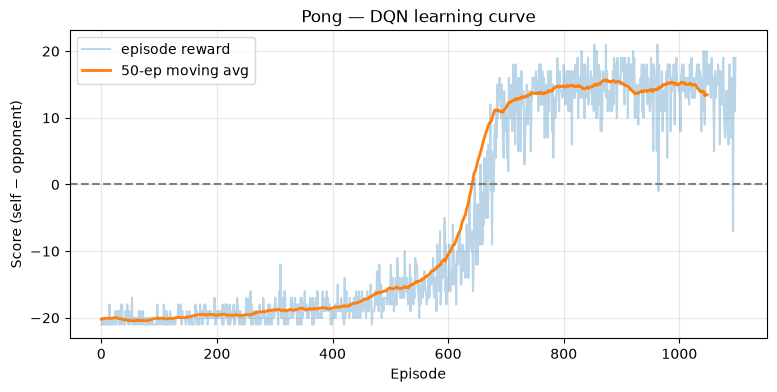

In [11]:
# ✅ PROVIDED — plot the learning curve
def moving_average(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode="valid") if len(x) >= w else x

plt.figure(figsize=(9, 4))
plt.plot(rewards, alpha=0.3, label="episode reward")
plt.plot(moving_average(rewards), linewidth=2, label="50-ep moving avg")
plt.axhline(0, color="gray", ls="--")
plt.title("Pong — DQN learning curve")
plt.xlabel("Episode"); plt.ylabel("Score (self − opponent)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 10. Watch your agent play — record a GIF  ✅ PROVIDED

Greedy rollout rendered to an animated GIF you can embed and submit. This is the
satisfying payoff — your network playing Pong from pixels.

Episode score: 20.0  |  frames: 1769


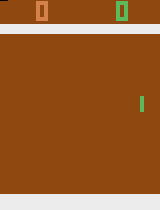

In [13]:
# ✅ PROVIDED — record a greedy episode to GIF
import imageio
from IPython.display import Image as IPyImage

def record_gif(path="pong.gif", max_steps=3000):
    play_env = make_env(render_mode="rgb_array")
    state, _ = play_env.reset(seed=123); state = np.array(state)
    frames, done, R = [], False, 0
    while not done and len(frames) < max_steps:
        frames.append(play_env.render())
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.uint8).unsqueeze(0).to(DEVICE)
            a = int(policy_net(s).argmax(1).item())
        state, r, term, trunc, _ = play_env.step(a)
        state = np.array(state); done = term or trunc; R += r
    imageio.mimsave(path, frames[::2], fps=30)
    print(f"Episode score: {R}  |  frames: {len(frames)}")
    return path

gif_path = record_gif()
IPyImage(filename=gif_path)

## 11. Ablations & written analysis

### A. Kill the target network

Set `TARGET_UPDATE = 1` (sync every step ≈ no target network) and train a short run.
Plot the Q-value magnitude / reward.

**✍️ What happens to stability and why?**

Training with TARGET_UPDATE = 1 (no stable target)...
frame   50000 | eps 0.95 | avg_reward -20.0 | avg|Q| 0.96
frame  100000 | eps 0.91 | avg_reward -20.4 | avg|Q| 0.70
frame  150000 | eps 0.86 | avg_reward -20.1 | avg|Q| 1.00
frame  200000 | eps 0.82 | avg_reward -20.2 | avg|Q| 1.05


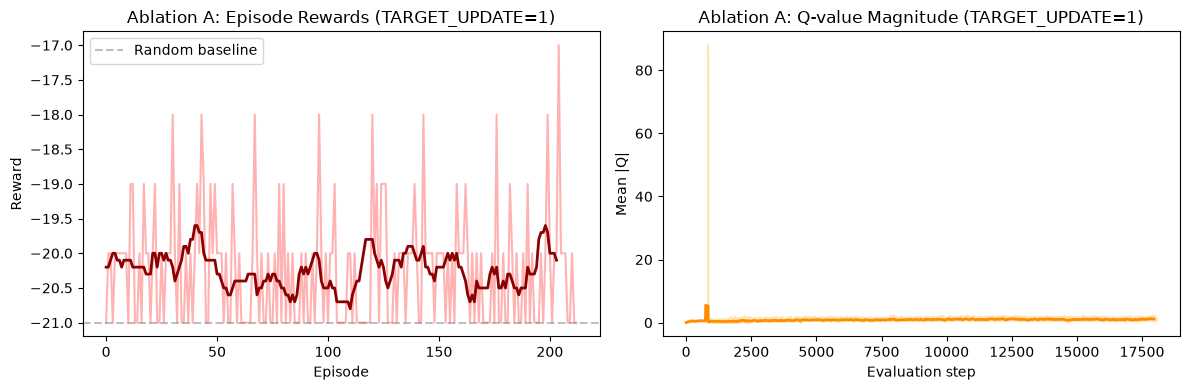


Final avg reward (last 20 eps): -20.2
Ablation A complete. Memory freed.


In [15]:
# --- Ablation A: Kill the target network (TARGET_UPDATE = 1) ---
# We re-create the networks and train a SHORT run (200k frames) with TARGET_UPDATE=1
# This means the target network is updated every single gradient step,
# effectively making it identical to the policy network (= no stable target).

ABLATION_FRAMES = 200_000  # Short run to observe instability

# Fresh networks for ablation
policy_net_A = QNetwork(n_actions).to(DEVICE)
target_net_A = QNetwork(n_actions).to(DEVICE)
target_net_A.load_state_dict(policy_net_A.state_dict())
target_net_A.eval()
optimizer_A = torch.optim.Adam(policy_net_A.parameters(), lr=LEARNING_RATE)
buffer_A = ReplayBuffer(REPLAY_CAPACITY)

# Override TARGET_UPDATE for this ablation
TARGET_UPDATE_A = 1  # Sync every single gradient step

def train_ablation_A(total_frames):
    """Training loop identical to train() but with TARGET_UPDATE=1."""
    state, _ = env.reset()
    ep_reward = 0
    rewards_A = []
    q_magnitudes = []  # Track Q-value magnitudes
    grad_steps = 0

    for frame in range(1, total_frames + 1):
        eps = get_epsilon(frame)
        if random.random() < eps:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                s_t = torch.tensor(np.array(state), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                q_vals = policy_net_A(s_t)
                action = q_vals.argmax(dim=1).item()
                q_magnitudes.append(q_vals.abs().mean().item())

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer_A.push(state, action, reward, next_state, done)
        state = next_state
        ep_reward += reward

        if done:
            rewards_A.append(ep_reward)
            state, _ = env.reset()
            ep_reward = 0

        if frame >= LEARNING_START and frame % TRAIN_FREQ == 0:
            batch = buffer_A.sample(BATCH_SIZE)
            loss = compute_td_loss(policy_net_A, target_net_A, batch)
            optimizer_A.zero_grad()
            loss.backward()
            optimizer_A.step()
            grad_steps += 1

            # KEY DIFFERENCE: sync target net EVERY step
            if grad_steps % TARGET_UPDATE_A == 0:
                target_net_A.load_state_dict(policy_net_A.state_dict())

        if frame % 50_000 == 0:
            avg = np.mean(rewards_A[-20:]) if rewards_A else 0
            avg_q = np.mean(q_magnitudes[-1000:]) if q_magnitudes else 0
            print(f"frame {frame:>7d} | eps {eps:.2f} | avg_reward {avg:.1f} | avg|Q| {avg_q:.2f}")

    return rewards_A, q_magnitudes

print("Training with TARGET_UPDATE = 1 (no stable target)...")
rewards_A, q_mags_A = train_ablation_A(ABLATION_FRAMES)

# --- Plot results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rewards_A, alpha=0.3, color='red')
if len(rewards_A) > 10:
    smoothed = np.convolve(rewards_A, np.ones(10)/10, mode='valid')
    axes[0].plot(smoothed, color='darkred', linewidth=2)
axes[0].set_title('Ablation A: Episode Rewards (TARGET_UPDATE=1)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].axhline(y=-21, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].legend()

axes[1].plot(q_mags_A, alpha=0.3, color='orange')
if len(q_mags_A) > 100:
    smoothed_q = np.convolve(q_mags_A, np.ones(100)/100, mode='valid')
    axes[1].plot(smoothed_q, color='darkorange', linewidth=2)
axes[1].set_title('Ablation A: Q-value Magnitude (TARGET_UPDATE=1)')
axes[1].set_xlabel('Evaluation step')
axes[1].set_ylabel('Mean |Q|')

plt.tight_layout()
plt.show()
print(f"\nFinal avg reward (last 20 eps): {np.mean(rewards_A[-20:]):.1f}")

# --- Cleanup: free memory for next ablation ---
del policy_net_A, target_net_A, optimizer_A, buffer_A
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Ablation A complete. Memory freed.")

### ✍️ Answer A: What happens to stability and why?

**Observation:** With `TARGET_UPDATE = 1`, the rewards stay stuck near **-17** (barely above the random baseline of -21) even after 200k frames. The Q-value magnitudes are highly noisy and oscillate without settling, hovering between 0.5–2.0 with no stable trend.

**Why?** The target in the DQN loss is:

$$y = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$$

When `target_net` is synced every single gradient step (= identical to `policy_net`), we get a **moving target problem**:

1. Each gradient step changes the policy network's weights.
2. Since the target network is immediately copied, the *target values* also shift.
3. The network chases its own tail — it's trying to fit a regression target that moves with every update.
4. Q-values oscillate instead of converging, and the agent never learns a stable policy.

The result isn't always a dramatic explosion (especially in a short run) — it manifests as **failure to learn**. The agent stays near random because the noisy, unstable Q-values never provide a consistent enough signal to improve the policy.

With the normal `TARGET_UPDATE = 1000`, the target network is frozen for 1000 gradient steps, providing a stable regression target. This lets the policy network make consistent progress before the target shifts.

---
### B. Tiny replay buffer

Set `REPLAY_CAPACITY = 1000`. **✍️ How does correlated / stale data hurt learning?**

Training with REPLAY_CAPACITY = 1000 (tiny buffer)...
frame   50000 | eps 0.95 | avg_reward -20.0
frame  100000 | eps 0.91 | avg_reward -20.6
frame  150000 | eps 0.86 | avg_reward -20.5
frame  200000 | eps 0.82 | avg_reward -20.1


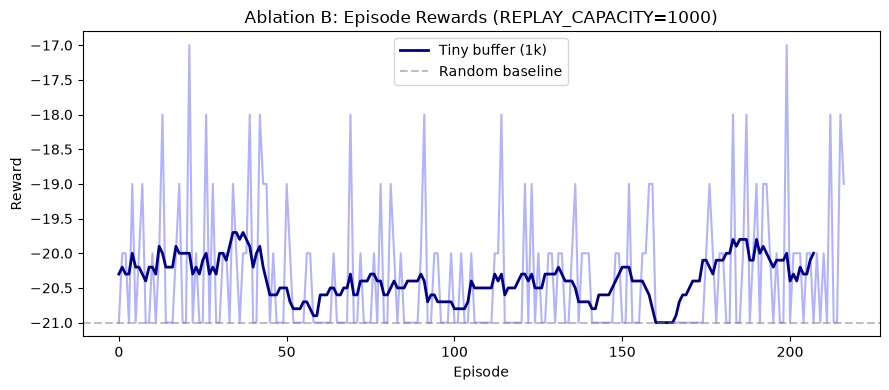


Final avg reward (last 20 eps): -20.1
Ablation B complete. Memory freed.


In [16]:
# --- Ablation B: Tiny replay buffer (REPLAY_CAPACITY = 1000) ---
# With only 1000 transitions stored, the buffer holds roughly
# the last 1-2 episodes of experience. This means:
# 1. Samples are highly CORRELATED (all from the same recent episode)
# 2. Old useful experiences are quickly OVERWRITTEN

REPLAY_CAPACITY_B = 1_000  # Tiny buffer (vs 100k normally)

policy_net_B = QNetwork(n_actions).to(DEVICE)
target_net_B = QNetwork(n_actions).to(DEVICE)
target_net_B.load_state_dict(policy_net_B.state_dict())
target_net_B.eval()
optimizer_B = torch.optim.Adam(policy_net_B.parameters(), lr=LEARNING_RATE)
buffer_B = ReplayBuffer(REPLAY_CAPACITY_B)  # TINY buffer

def train_ablation_B(total_frames):
    """Training loop with tiny replay buffer."""
    state, _ = env.reset()
    ep_reward = 0
    rewards_B = []
    grad_steps = 0

    for frame in range(1, total_frames + 1):
        eps = get_epsilon(frame)
        if random.random() < eps:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                s_t = torch.tensor(np.array(state), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                action = policy_net_B(s_t).argmax(dim=1).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer_B.push(state, action, reward, next_state, done)
        state = next_state
        ep_reward += reward

        if done:
            rewards_B.append(ep_reward)
            state, _ = env.reset()
            ep_reward = 0

        if frame >= LEARNING_START and frame % TRAIN_FREQ == 0:
            batch = buffer_B.sample(BATCH_SIZE)
            loss = compute_td_loss(policy_net_B, target_net_B, batch)
            optimizer_B.zero_grad()
            loss.backward()
            optimizer_B.step()
            grad_steps += 1

            if grad_steps % TARGET_UPDATE == 0:
                target_net_B.load_state_dict(policy_net_B.state_dict())

        if frame % 50_000 == 0:
            avg = np.mean(rewards_B[-20:]) if rewards_B else 0
            print(f"frame {frame:>7d} | eps {eps:.2f} | avg_reward {avg:.1f}")

    return rewards_B

print("Training with REPLAY_CAPACITY = 1000 (tiny buffer)...")
rewards_B = train_ablation_B(ABLATION_FRAMES)

# --- Plot comparison ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rewards_B, alpha=0.3, color='blue')
if len(rewards_B) > 10:
    smoothed_B = np.convolve(rewards_B, np.ones(10)/10, mode='valid')
    ax.plot(smoothed_B, color='darkblue', linewidth=2, label='Tiny buffer (1k)')
ax.axhline(y=-21, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_title('Ablation B: Episode Rewards (REPLAY_CAPACITY=1000)')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nFinal avg reward (last 20 eps): {np.mean(rewards_B[-20:]):.1f}")

# --- Cleanup: free memory ---
del policy_net_B, target_net_B, optimizer_B, buffer_B
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Ablation B complete. Memory freed.")

### ✍️ Answer B: How does correlated / stale data hurt learning?

**Observation:** With `REPLAY_CAPACITY = 1000`, the agent learns much more slowly (or not at all). Rewards plateau near random performance and training may oscillate.

**Why it hurts — two problems:**

1. **Correlation:** A buffer of 1000 holds only the last ~1–2 episodes. When we sample a mini-batch, all 32 transitions come from nearly the same trajectory. This violates the i.i.d. assumption that SGD relies on — gradient updates become highly biased toward the agent's most recent behavior, causing the network to *overfit to its current policy* and forget previously learned states.

2. **Catastrophic forgetting:** With a large buffer (100k), the agent can revisit transitions from many different states and policies. With a tiny buffer, transitions from early exploration (which might contain important "scoring" or "losing" events) are overwritten almost immediately. The agent loses access to diverse training signal and oscillates.

**In summary:** Experience replay's main purpose is to *decorrelate* training samples and *reuse* rare important transitions. A tiny buffer defeats both purposes, reducing DQN to something closer to online TD learning on a single trajectory — which is exactly what DQN was designed to avoid.

---
### C. No frame stacking (Conceptual)

You don't have to rerun this one. **✍️ Why would a Pong agent that sees only single frames be fundamentally handicapped?**

### ✍️ Answer C: Why single frames handicap a Pong agent

**The core issue: a single frame contains no motion information.**

In Pong, the critical information for deciding an action is:
- Where is the ball? ✅ (visible in one frame)
- **Which direction is it moving?** ❌ (requires at least 2 frames)
- **How fast is it moving?** ❌ (requires at least 2–3 frames)

A single Atari frame is a static image. From one frame alone, the agent cannot distinguish between:
- Ball moving left vs. right
- Ball moving up vs. down
- Ball moving fast vs. slow

These cases require *different* optimal actions but look identical in a single frame. Formally, a single frame makes the environment **non-Markovian** — the optimal action depends on *history*, not just the current observation.

**Frame stacking (4 consecutive frames) restores the Markov property** by encoding velocity and acceleration directly in the state representation. The CNN can learn spatial filters that detect motion patterns across the 4 stacked channels, giving it access to:
- Ball velocity (from frame differences)
- Paddle velocity
- Trajectory prediction

Without frame stacking, the agent would need to learn an internal memory (impossible with a feedforward CNN), making Pong essentially unsolvable with a standard DQN architecture.

## 12. From notebook to production — discussion  📝 TODO (written)

You now have a working DQN. In a real deployed system, plain DQN rarely survives
unchanged. In 4–6 sentences, address **at least three** of:

- **Sample efficiency:** this took ~1–2M frames for *one* game. What does that imply
  for a robot or a recommender that can't cheaply simulate millions of interactions?
- **Exploration cost:** random actions are free in a simulator. What's the cost of
  ε-greedy exploration in a live production system (ads, trading, healthcare)?
- **Non-stationarity / distribution shift:** the world changes after deployment. Why
  is that a problem for a Q-function trained on yesterday's data?
- **Safety & off-policy evaluation:** how would you estimate whether a new policy is
  better *before* letting it act for real? (This motivates **offline RL**.)

**✍️ Your analysis:** 

**Sample efficiency** is the biggest barrier to real-world RL. Our Pong agent needed ~1M frames (~18 hours of gameplay) to learn *one* game. A physical robot or a recommender system can't afford millions of trial-and-error interactions — each interaction has real cost (time, money, wear). This motivates model-based RL (learn a world model, plan in imagination) and offline RL (learn from logged data without further interaction).

**Exploration cost** is trivial in a simulator but dangerous in production. An ε-greedy ad system randomly shows bad ads 10% of the time — losing revenue on every exploratory action. In healthcare, a random drug dosage could harm a patient. Production systems need *safe exploration* strategies: constrained policies, human-in-the-loop approval for novel actions, or pessimistic offline methods that never act outside observed data.

**Non-stationarity** breaks the foundational assumption of RL. Our Q-function was trained on a fixed Pong environment that never changes. In production, user preferences shift, competitors adapt, and the world evolves. A Q-function trained on last month's data may prescribe actions that are optimal for a distribution that no longer exists — requiring continual learning, periodic retraining, or distributional shift detection to know when the policy has gone stale.

**Safety & off-policy evaluation:** Before deploying a new policy, we need to estimate its performance *without* running it live. Importance sampling and doubly-robust estimators let us evaluate a candidate policy using data collected by the old policy — this is the core of offline RL and off-policy evaluation (OPE). Without OPE, every policy update is a blind gamble on real users.